# 03 — Negative Controls

In this notebook, we stress-test the spatial structure result. Is the standing wave a genuine physical feature, or just an artefact of applying DMD to noisy data? We use three controls:
1. **Off-band control:** What happens if we run the exact same pipeline on a background frequency band with no mode?
2. **Channel Envelope Check:** Is the amplitude shape just the raw instrument's spatial sensitivity?
3. **Channel Permutation:** If we randomly shuffle the physical channel order, does the mode shape disappear?

In [1]:
# Imports

import sys, os
sys.path.insert(0, os.path.abspath('../..')) 
sys.path.insert(0, os.path.abspath('..'))     
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import median_filter

from src import config as cfg
from src.math_helpers import load_data
from src.spatial_math import spatial_mode_analysis, spatial_mode_evolution
from src.negative_controls import (
    fit_offband_windows, analyse_offband_control, 
    compute_channel_envelope, channel_permutation_control
)

In [2]:
# Load context and previously cached real mode traces

ctx = load_data()

with open(os.path.join(cfg.OUT, 'discharge1_dmd_traces.pkl'), 'rb') as fh:
    rows = pickle.load(fh)

from src.dmd_tracking import track_mode
track = track_mode(rows)
spatial = spatial_mode_analysis(ctx, track)
evol = spatial_mode_evolution(ctx, track, spatial)

## 1. Off-Band Control

We picked a frequency band (`330 - 430 kHz`) that is featureless broadband noise. We run the exact same sliding window fit on this band. Note that again the lines on the overlap plot are constructed from the median of seven adjacent windows. 

In [3]:
ctrl_cache = os.path.join(cfg.OUT, 'discharge1_control_traces.pkl')
ctrl_rows = fit_offband_windows(ctx, checkpoint_path=ctrl_cache)
ctrl = analyse_offband_control(ctx, ctrl_rows)

print(f"Off-band control processed {len(ctrl['t'])} windows.")

Off-band control processed 164 windows.


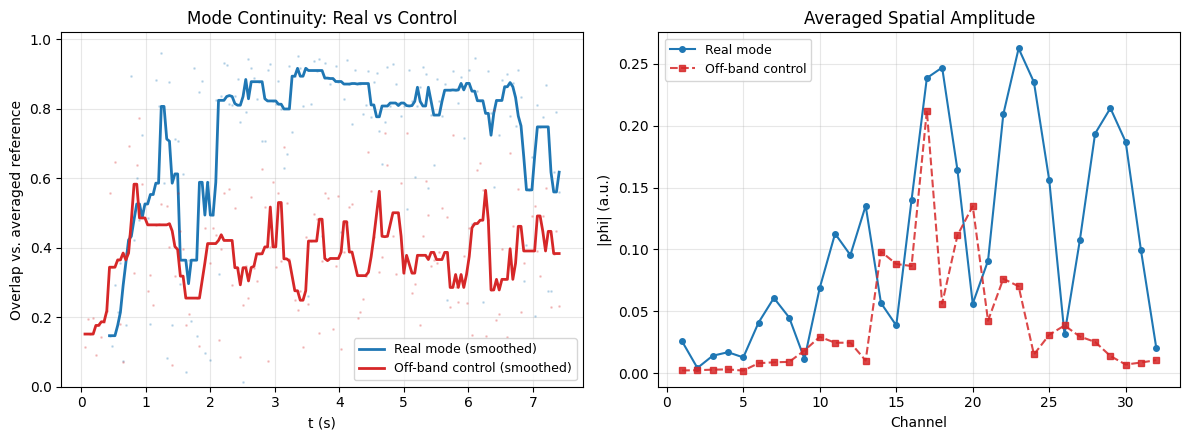

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Continuity Overlap Comparison
sw = min(7, len(evol['overlap_ref']) - 1 or 1)
sw_c = min(7, len(ctrl['overlap_ref']) - 1 or 1)

ax[0].plot(evol['t'], evol['overlap_ref'], '.', ms=2, color='tab:blue', alpha=0.2)
ax[0].plot(evol['t'], median_filter(evol['overlap_ref'], size=max(1, sw)), 
           '-', lw=2, color='tab:blue', label='Real mode (smoothed)')

ax[0].plot(ctrl['t'], ctrl['overlap_ref'], '.', ms=2, color='tab:red', alpha=0.2)
ax[0].plot(ctrl['t'], median_filter(ctrl['overlap_ref'], size=max(1, sw_c)), 
           '-', lw=2, color='tab:red', label='Off-band control (smoothed)')

ax[0].set_ylim(0, 1.02)
ax[0].set_ylabel('Overlap vs. averaged reference')
ax[0].set_xlabel('t (s)')
ax[0].set_title('Mode Continuity: Real vs Control')
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

# Spatial Profile Comparison (Amplitude)
ax[1].plot(spatial['ch'], np.abs(spatial['phi_mean']), 'o-', ms=4, color='tab:blue', label="Real mode")
ax[1].plot(spatial['ch'], np.abs(ctrl['phi_mean_ref']), 's--', ms=4, color='tab:red', alpha=0.85, label="Off-band control")
ax[1].set_ylabel('|phi| (a.u.)')
ax[1].set_xlabel('Channel')
ax[1].set_title('Averaged Spatial Amplitude')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 2. Channel Envelope Check

In the spatial structure plot above, we still see something similar to a nodal pattern, although the nodes are far less defined than in the real mode case. There also still appears to be some form of a Gaussian envelope. To check whether this is an artefact of the instrument, we computed the raw signal RMS (without DMD). If the raw signal has the same envelope, then it is just the instrument and not evidence of a mode.  

The grey line shows the broadband RMS, which appears to show a problem with the 12th channel. Since the red and blue lines are basically identical, we know that the envelope we see in both the on- and off-band cases is not a mode signature and instead just an artefact of the instrument's sensitivity profile itself.

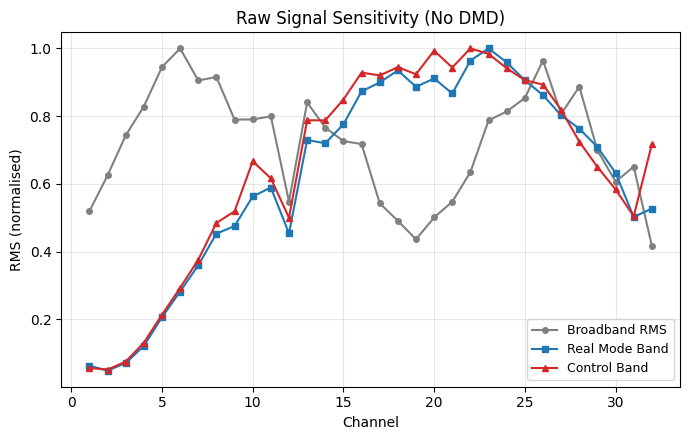

In [5]:
env = compute_channel_envelope(ctx, spatial['phi_mean'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(env['ch'], env['broadband_rms'] / env['broadband_rms'].max(), 'o-', ms=4, color='grey', label='Broadband RMS')
ax.plot(env['ch'], env['search_rms'] / env['search_rms'].max(), 's-', ms=4, color='tab:blue', label='Real Mode Band')
ax.plot(env['ch'], env['control_rms'] / env['control_rms'].max(), '^-', ms=4, color='tab:red', label='Control Band')

ax.set_xlabel('Channel')
ax.set_ylabel('RMS (normalised)')
ax.set_title('Raw Signal Sensitivity (No DMD)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Channel Permutation

If the standing wave nodes (where amplitude dips and phase flips) are real physical features, they rely on physical adjacency. If we randomly shuffle the channels, the PCA math ($R^2$) will stay exactly the same (because it's order invariant), but the physical correspondence between nodes and dips should collapse.

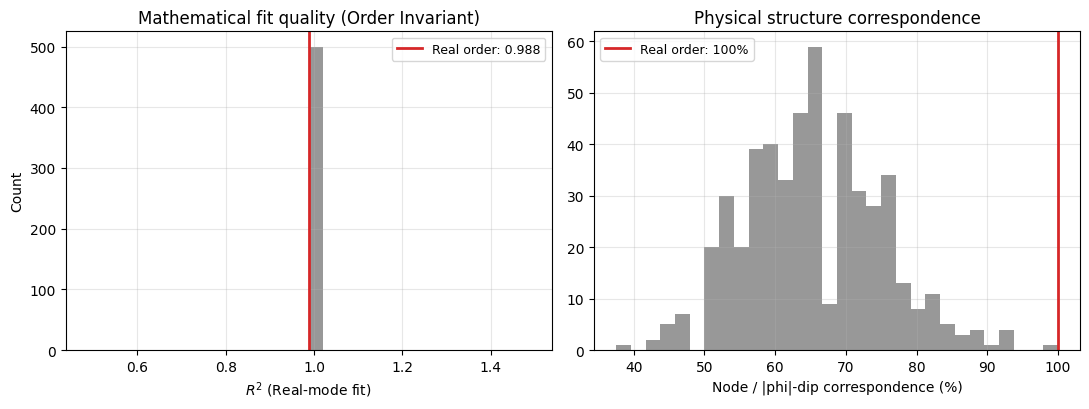

In [6]:
t_lo, t_hi = np.percentile(track['t'], [33, 67])
phi_stack = track['phi'][(track['t'] >= t_lo) & (track['t'] <= t_hi)]

perm = channel_permutation_control(phi_stack)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# R2 Histogram
ax[0].hist(perm['r2_perm'], bins=30, color='tab:grey', alpha=0.8)
ax[0].axvline(perm['r2_baseline'], color='tab:red', lw=2, label=f"Real order: {perm['r2_baseline']:.3f}")
ax[0].set_xlabel('$R^2$ (Real-mode fit)')
ax[0].set_ylabel('Count')
ax[0].legend(fontsize=9)
ax[0].set_title('Mathematical fit quality (Order Invariant)')
ax[0].grid(alpha=0.3)

# Node/Dip Histogram
frac_perm_finite = perm['frac_perm'][np.isfinite(perm['frac_perm'])] * 100
ax[1].hist(frac_perm_finite, bins=30, color='tab:grey', alpha=0.8)
ax[1].axvline(perm['frac_baseline'] * 100, color='tab:red', lw=2, label=f"Real order: {perm['frac_baseline']*100:.0f}%")
ax[1].set_xlabel('Node / |phi|-dip correspondence (%)')
ax[1].legend(fontsize=9)
ax[1].set_title('Physical structure correspondence')
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

As can be seen above, the $R^2$ value remains unchanged across all 500 shuffled channel runs, while the physical structure correspondence shows a bell curve centred at roughly 65%, which is associated with random chance. Thus the extracted standing wave relies on the spatial adjacency of the detectors.